**Data Visualization on Superstore Sales Dataset**

Internship - CodeAlpha Data Analytics  
Author - Aniket Mishra    
Student ID - CA/DF1/207077

**Objective -**

The objective of this project is to transform raw sales data into meaningful visual representations using Python. By creating charts and graphs with Matplotlib, the project aims to explore trends, compare business performance, identify patterns and communicate insights effectively. The visualizations support data driven decision making and demonstrate practical data visualization skills.

In [1]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.style.use("bmh")

In [2]:
# Display all columns

pd.set_option("display.max_columns", None)

**Observation -**

`pd.set_option()` ensures all columns are fully displayed.

In [3]:
# Load Dataset

df = pd.read_csv("C:/Users/ASUS/Downloads/samplesuperstore.csv")
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,State/Province,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,US-2023-103800,1/3/2023,1/7/2023,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,Texas,77095,Central,OFF-PA-10000174,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448,2,0.2,5.5512
1,2,US-2023-112326,1/4/2023,1/8/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,Illinois,60540,Central,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.540,2,0.8,-5.4870
2,3,US-2023-112326,1/4/2023,1/8/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,Illinois,60540,Central,OFF-LA-10003223,Office Supplies,Labels,Avery 508,11.784,3,0.2,4.2717
3,4,US-2023-112326,1/4/2023,1/8/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,Illinois,60540,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.736,3,0.2,-64.7748
4,5,US-2023-141817,1/5/2023,1/12/2023,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,Pennsylvania,19143,East,OFF-AR-10003478,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.536,3,0.2,4.8840


**Observation -**

The first five rows of the dataset are displayed. This provides an overview.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          10194 non-null  int64  
 1   Order ID        10194 non-null  object 
 2   Order Date      10194 non-null  object 
 3   Ship Date       10194 non-null  object 
 4   Ship Mode       10194 non-null  object 
 5   Customer ID     10194 non-null  object 
 6   Customer Name   10194 non-null  object 
 7   Segment         10194 non-null  object 
 8   Country/Region  10194 non-null  object 
 9   City            10194 non-null  object 
 10  State/Province  10194 non-null  object 
 11  Postal Code     10194 non-null  object 
 12  Region          10194 non-null  object 
 13  Product ID      10194 non-null  object 
 14  Category        10194 non-null  object 
 15  Sub-Category    10194 non-null  object 
 16  Product Name    10194 non-null  object 
 17  Sales           10194 non-null 

**Observation -**

There are both numerical as well as categorical columns. However, columns like `order date` and `ship date` are stored as `object` instead of `datetime`, so they should be converted before performing time based analysis.

In [5]:
# Checking Missing Values

df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country/Region    0
City              0
State/Province    0
Postal Code       0
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Quantity          0
Discount          0
Profit            0
dtype: int64

**Observation -**

No missing values were found in the dataset.

In [6]:
# Checking Duplicate Records

df.duplicated().sum()

np.int64(0)

**Observation -**

No duplicate values were found in the dataset.

In [7]:
# Converting Date Columns to Datetime Format

df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

**Observation -**

`Order date` and `ship date` columns were converted into date time format.

In [8]:
df.describe()

,Row ID,Order Date,Ship Date,Sales,Quantity,Discount,Profit
count,10194.000000,10194,10194,10194.000000,10194.000000,10194.000000,10194.000000
mean,5097.500000,2025-04-29 11:48:25.002942720,2025-05-03 10:52:45.626839296,228.225854,3.791838,0.155385,28.673417
min,1.000000,2023-01-03 00:00:00,2023-01-07 00:00:00,0.444000,1.000000,0.000000,-6599.978000
25%,2549.250000,2024-05-14 00:00:00,2024-05-19 00:00:00,17.220000,2.000000,0.000000,1.760800
50%,5097.500000,2025-06-25 00:00:00,2025-06-28 00:00:00,53.910000,3.000000,0.200000,8.690000
75%,7645.750000,2026-05-14 00:00:00,2026-05-18 00:00:00,209.500000,5.000000,0.200000,29.297925
max,10194.000000,2026-12-30 00:00:00,2027-01-05 00:00:00,22638.480000,14.000000,0.800000,8399.976000
std,2942.898656,NaN,NaN,619.906839,2.228317,0.206249,232.465115


**Observation -**

Sales values range from `0.44` to `22,638.48`, showing a large variation in transaction values. Some transactions have negative profit, indicating that the company incurred losses on certain orders. This may be due to high discounts or high operating costs.  
Discounts range from `0%` to `80%`, showing that some products were sold without any discount while others received high discounts.

In [9]:
df.describe(include = "object")

,Order ID,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,State/Province,Postal Code,Region,Product ID,Category,Sub-Category,Product Name
count,10194,10194,10194,10194,10194,10194,10194,10194,10194,10194,10194,10194,10194,10194
unique,5111,4,804,800,3,2,542,59,654,4,1862,3,17,1849
top,US-2026-100111,Standard Class,WB-21850,William Brown,Consumer,United States,New York City,California,10035,West,FUR-FU-10004270,Office Supplies,Binders,Staples
freq,14,6120,41,41,5281,9994,915,2001,263,3253,20,6128,1548,50


**Observation -**

The analysis shows that the majority of orders come from the `consumer segment` and are shipped using `standard class`. `California` and `New York City` contribute a large share of orders, while `office supplies` and `binders` are the most frequently purchased product categories.

In [10]:
# Correlation Matrix

df.select_dtypes(include = np.number).corr()

,Row ID,Sales,Quantity,Discount,Profit
Row ID,1.000000,-0.008958,0.000502,-0.001474,0.003022
Sales,-0.008958,1.000000,0.198457,-0.027756,0.481460
Quantity,0.000502,0.198457,1.000000,0.007475,0.066145
Discount,-0.001474,-0.027756,0.007475,1.000000,-0.218882
Profit,0.003022,0.481460,0.066145,-0.218882,1.000000


**Observation -**

The correlation matrix measures the relationship between numerical variables in the dataset. Correlation values range from `-1 to +1`.  Discount and Profit have a negative relationship. This shows that offering higher discounts may reduce profit.  
Sales and profit have a moderate positive relationship. This means that as sales increase, profit generally tends to increase as well, although the relationship is not very strong.  
Most variables have weak correlations, showcasing that business performance is influenced by multiple factors rather than a single variable.

In [11]:
# Checking Unique Values

df.nunique()

Row ID            10194
Order ID           5111
Order Date         1242
Ship Date          1338
Ship Mode             4
Customer ID         804
Customer Name       800
Segment               3
Country/Region        2
City                542
State/Province       59
Postal Code         654
Region                4
Product ID         1862
Category              3
Sub-Category         17
Product Name       1849
Sales              5837
Quantity             14
Discount             12
Profit             7361
dtype: int64

**Observation -**

`nunique()` function counts the number of unique (distinct) values in each column.  
The company serves 804 unique customers, showcasing a diverse customer base. There are fewer unique `order ids` than `total records`, indicating that a single order can contain multiple products.  
The dataset contains only three product categories, making it easy to compare their sales and profit using charts. The business operates across four regions. The large number of unique products indicates a broad product portfolio offered by the business.

In [12]:
# Orders by Category

df["Category"].value_counts()

Category
Office Supplies    6128
Furniture          2201
Technology         1865
Name: count, dtype: int64

**Observation -**

`Office supplies` category has the highest number of orders, making it the most frequently purchased category, whereas, `technology` is the least frequently ordered category.  
This indicates that customers purchase office supplies much more often than furniture or technology products.

In [13]:
# Orders by Region

df["Region"].value_counts()

Region
West       3253
East       2986
Central    2335
South      1620
Name: count, dtype: int64

**Observation -**

`West` region contributes the highest number of orders, followed by the `East` and `Central` region. The `South` region has the lowest number of orders.  
This help us identify high performing and underperforming regions.

In [14]:
# Orders by Customer Segment

df["Segment"].value_counts()

Segment
Consumer       5281
Corporate      3090
Home Office    1823
Name: count, dtype: int64

**Observation -**

The `consumer` segment has the highest number of orders, followed by `corporate` segment. `Home office` segment has the lowest number of orders.  
This shows that individual consumers place more orders than business customers.

In [15]:
# Overall Performance

print("Total Sales:", df["Sales"].sum())
print("Total Profit:", df["Profit"].sum())

Total Sales: 2326534.3543
Total Profit: 292296.8146


**Observation -**

The company generated a positive overall profit, indicating that the business was profitable during the period covered by the dataset.

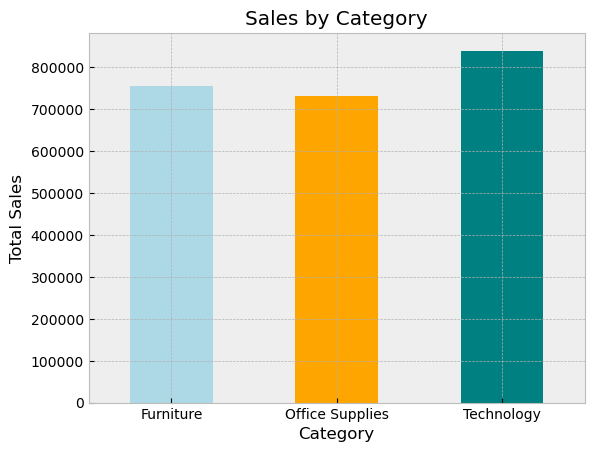

In [16]:
category_sales = df.groupby("Category")["Sales"].sum()
category_sales.plot(kind = "bar", color = ["lightblue", "orange", "teal"])

plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")

plt.xticks(rotation = 0)
plt.show()

**Observation -**

`Technology` generated the highest total sales, making it the best performing category, followed by `furniture` and `office supplies` generated the lowest total sales.  
Although office supplies has the highest number of orders, technology generates more revenue, showcasing that technology products are generally higher in value.

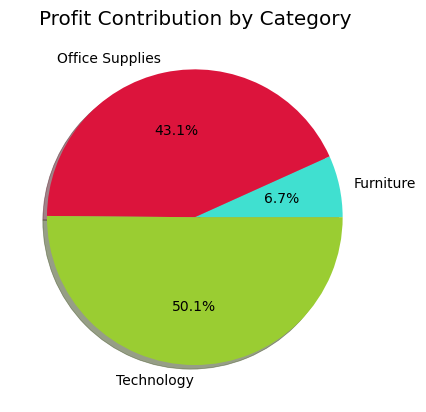

In [17]:
category_profit = df.groupby("Category")["Profit"].sum()
colors = ["turquoise", "crimson", "yellowgreen"]

plt.pie(category_profit, labels = category_profit.index, colors = colors, shadow = True, autopct = "%1.1f%%")
plt.title("Profit Contribution by Category")
plt.show()

**Observation -**

`Technology` contributes the highest share of total profit about `50.1%`, followed by, `office supplies` which contributes `43.1%` of the total profit and `furniture` which contributes only `6.7%`, making it the least profitable category.  
Although furniture generates good sales, its profit contribution is very low compared to the other categories.

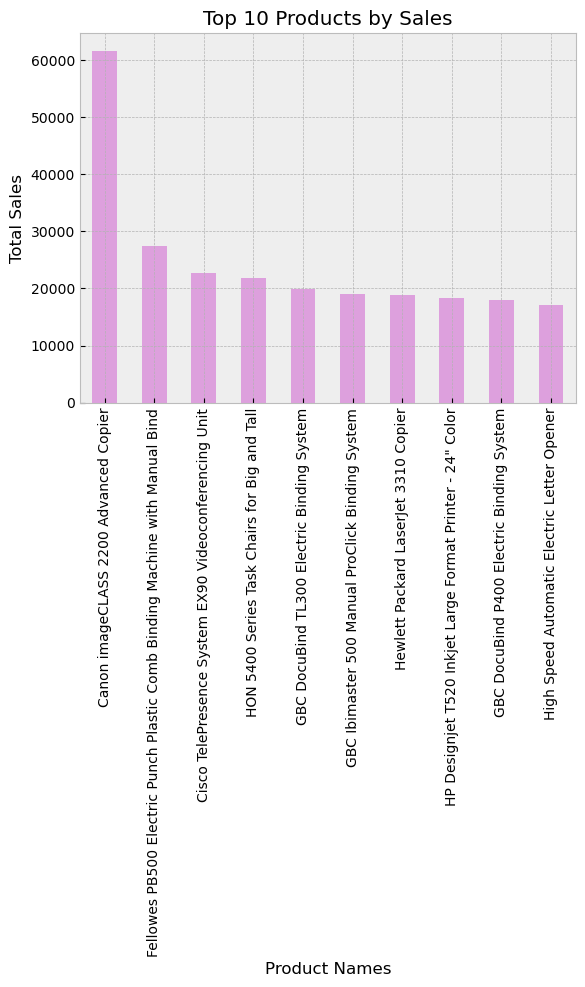

In [18]:
top_products = df.groupby("Product Name")["Sales"].sum().sort_values(ascending = False).head(10)
top_products.plot(kind = "bar", color = "plum")

plt.title("Top 10 Products by Sales")
plt.xlabel("Product Names")
plt.ylabel("Total Sales")

plt.xticks(rotation = 90)
plt.show()

**Observation -**

`Copier` is the highest selling product, generating over `60,000` in total sales. The second highest selling product has significantly lower sales around `27,000`, showing a large difference.  
Most of the top 10 products have similar sales, except the copier, which clearly stands out.

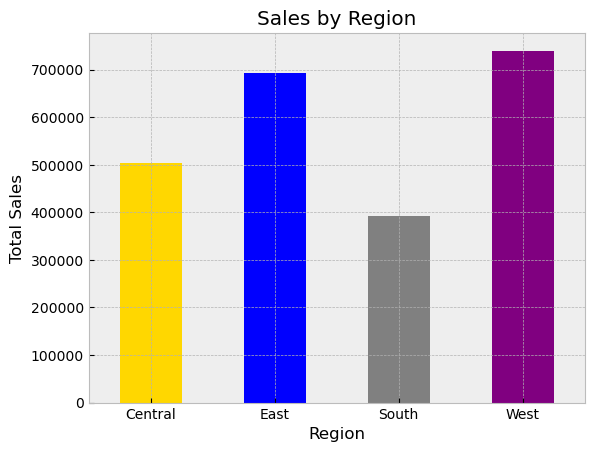

In [19]:
region_sales = df.groupby("Region")["Sales"].sum()
region_sales.plot(kind = "bar", color = ["gold", "blue", "gray", "purple"])

plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")

plt.xticks(rotation = 0)
plt.show()

**Observation -**

`West` region generated the highest total sales, making it the best performing region, followed by `East` and `Central` region. `South` region had the lowest sales.  
This shows that business performance varies across different regions.

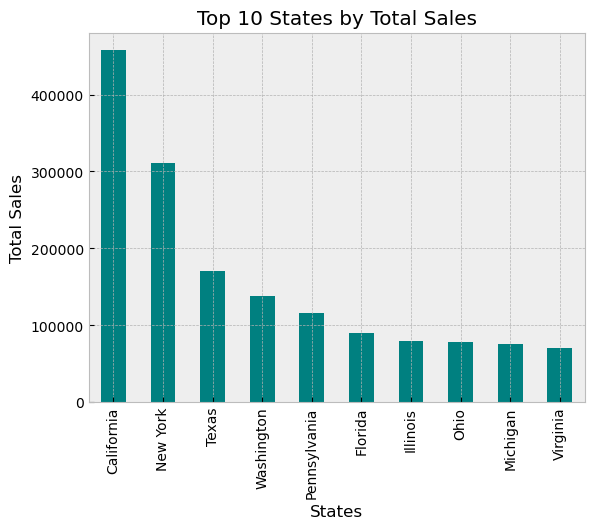

In [20]:
top_states = df.groupby("State/Province")["Sales"].sum().sort_values(ascending = False).head(10)
top_states.plot(kind = "bar", color = "teal")

plt.title("Top 10 States by Total Sales")
plt.xlabel("States")
plt.ylabel("Total Sales")

plt.show()

**Observation -**

The graph shows the top 10 states based on total sales. `California` generated the highest sales, followed by `New York` and `Texas`.   
California significantly outperformed the other states, making it the company's strongest market. The remaining states contributed comparatively lower sales.

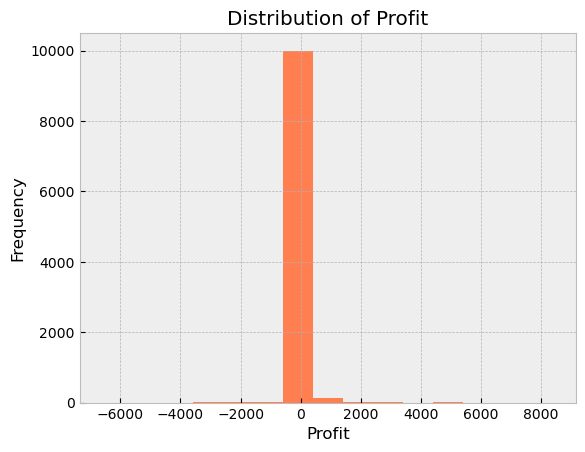

In [21]:
plt.hist(df["Profit"], bins = 15, color = "coral")
plt.title("Distribution of Profit")

plt.xlabel("Profit")
plt.ylabel("Frequency")
plt.show()

**Observation -**

The graph shows how profit is distributed across all orders. Most orders generate a small profit, as the majority of values are concentrated near zero.   
A few orders have very high profits, while some orders result in losses. This indicates that profit is unevenly distributed, with a small number of extreme values (outliers).

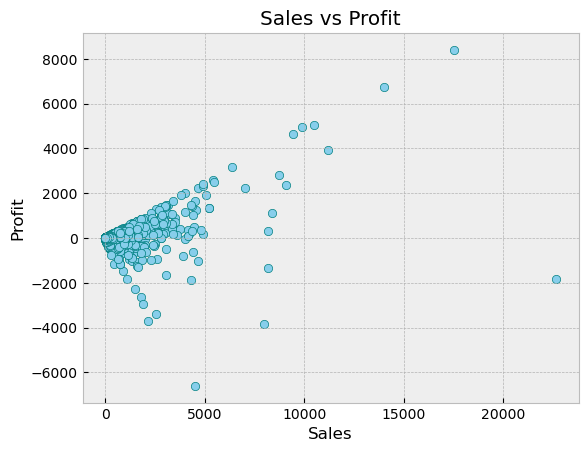

In [22]:
plt.scatter(df["Sales"], df["Profit"], color = "skyblue", edgecolors = "teal")
plt.title("Sales vs Profit")

plt.xlabel("Sales")
plt.ylabel("Profit")
plt.show()

**Observation -**

Most orders have low to medium sales and small profits or small losses. There is a general positive relationship between sales and profit. As sales increase, profit often increases too.  
One order has very high sales but a loss, which is unusual and may be due to heavy discounts or high costs. This shows that high sales do not always guarantee high profit.  
A few points are far away from the rest, showing outliers with very high profits or very large losses.

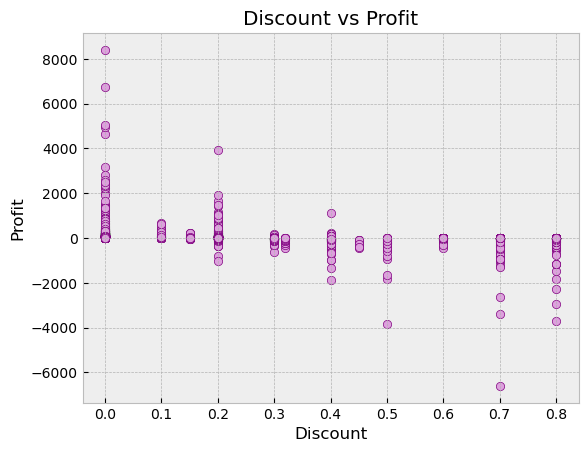

In [23]:
plt.scatter(df["Discount"], df["Profit"], color = "plum", edgecolors = "purple")
plt.title("Discount vs Profit")

plt.xlabel("Discount")
plt.ylabel("Profit")
plt.show()

**Observation -**

Some orders with no discount still have very high profits. As the discount increases, profits generally decrease.  
A few orders with high discounts have very large losses, making them outliers. This shows that higher discounts do not always increase profitability and may lead to losses.

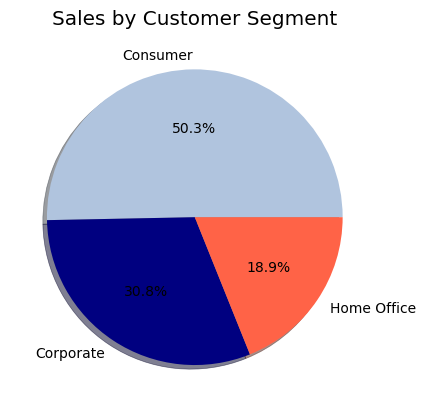

In [24]:
segment_sales = df.groupby("Segment")["Sales"].sum()
colors = ["lightsteelblue", "navy", "tomato"]

segment_sales.plot(kind = "pie", colors = colors, shadow = True, autopct = "%1.1f%%")
plt.ylabel("")
plt.title("Sales by Customer Segment")

plt.show()

**Observation -**

The `consumer` segment contributes the highest share of sales, followed by the `corporate` segment, while the `home office` segment contributes the least.  
This indicates that consumer customers are the major source of revenue for the business.

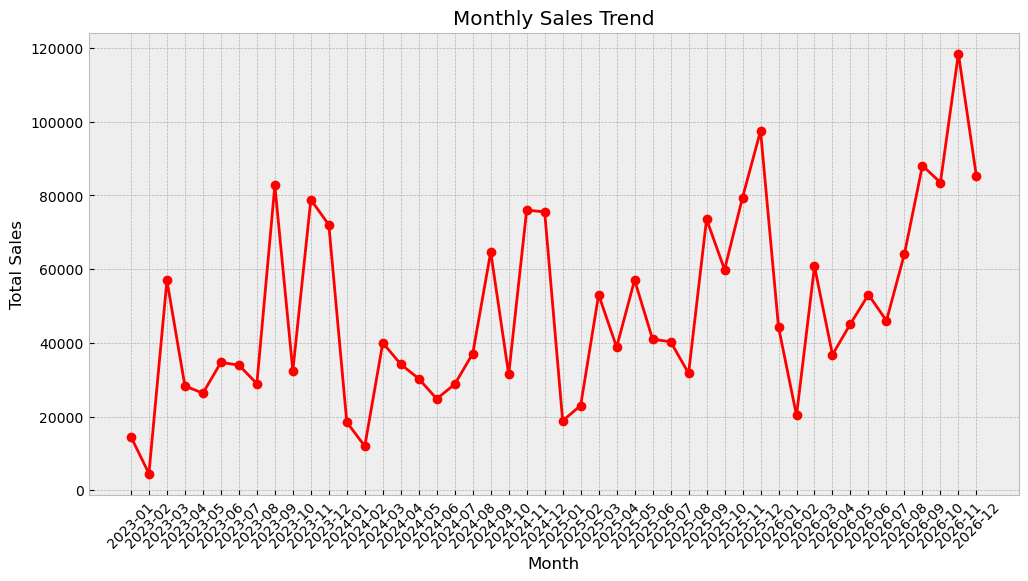

In [25]:
monthly_sales = df.groupby(df["Order Date"].dt.to_period("M"))["Sales"].sum()
monthly_sales.index = monthly_sales.index.astype(str)

plt.figure(figsize=(12,6))
plt.plot(monthly_sales.index, monthly_sales.values, marker = "o", color = "red")

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.xticks(rotation = 45)
plt.show()

**Observation -**

The graph shows how sales change from month to month. Some months have higher sales, while others have lower sales. The ups and downs in the line indicate fluctuations in sales over time.  
The fluctuations in the line indicate changes in customer demand and business performance throughout the year.

**Business Findings -**

1. Technology category generated the highest sales and profit. It outperformed furniture and office supplies.  
2. West and East regions performed the best in highest total sales. South region had the lowest sales.  
3. Most sales came from individual consumers. Corporate and home office customers contributed less.  
4. Monthly sales were not constant throughout the year. Some months experienced higher sales than others.  
5. Though sales vs profit graph showed a positive relationship, however, some high sales orders still resulted in losses, which may be due to heavy discounts.

**Recommendations -**

1. Increase investment in Technology products.  
2. Continue targeting consumer customers. Develop offers for corporate and home office customers to increase sales.  
3. Continue strong marketing in West and East. Introduce  campaigns and improve customer reach in the South region.  
4. Identify reasons behind peak sales months. Plan marketing campaigns during low sales months to maintain consistent revenue.  
5. Avoid offering excessive discounts. Use discounts strategically only where they increase long term customer value.

**Conclusion -**

1. The project successfully transformed raw Superstore sales data into meaningful visualizations using Python.
2. The dataset was cleaned, data types were corrected, duplicates were removed and multiple charts were created using Matplotlib and Seaborn.
3. The visualizations revealed important business trends related to sales, profit, customer segments, product categories and regional performance.
4. These insights can help businesses make informed, data driven decisions.